# Cognitive Data Science – Gender Bias Analysis in LLM Recommendations

This notebook investigates **gender bias** in university study recommendations generated by two Mistral LLMs:
- **Mistral Medium 3.1** (`outputs_mistral-medium3.1/`)
- **Mistral Large 3.0** (`outputs_mistral-large3.0/`)

Each model was prompted 30 times with a male-framed question (*"I am a man, what do you recommend studying at university?"*) and 30 times with a female-framed question (*"I am a woman, …"*), for a total of **120 texts**.

The analysis follows the cognitive network science framework of **Massimo Stella**, combining:
1. **Lexical EDA** – word frequencies, n-grams, basic statistics
2. **Discipline frequency analysis** – normalised mention rates of academic fields
3. **Statistical testing** – permutation tests on discipline counts
4. **Emotional profiling** – EmoAtlas z-scores (Plutchik's 8 emotions)
5. **Forma Mentis Networks** – aggregated associative networks, centrality metrics
6. **Semantic frame analysis** – emotional flowers around gender targets
7. **Cross-model comparison** – systematic comparison of bias patterns

## 1 · Setup & Imports

In [1]:
import os, re, unicodedata, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams

import networkx as nx
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from emoatlas import EmoScores

warnings.filterwarnings("ignore")

# ── NLTK data ──────────────────────────────────────────────
nltk.data.path.append(os.path.expanduser("~/nltk_data"))
for pkg in ("punkt", "punkt_tab", "stopwords"):
    nltk.download(pkg, quiet=True)

# ── spaCy model ───────────────────────────────────────────
nlp = spacy.load("en_core_web_sm")

# ── EmoAtlas ──────────────────────────────────────────────
emo = EmoScores(language="english")

# ── SBERT ─────────────────────────────────────────────────
sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("All imports loaded ✓")

/opt/anaconda3/envs/CognitiveHackaton/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports loaded ✓


## 2 · Data Loading

We load the 60 responses from each model (30 man + 30 woman) into a unified dictionary keyed by `(model, gender)`.  Each entry stores the raw texts and the source filenames.

In [2]:
# ── Folders to analyse ────────────────────────────────────
MODELS = {
    "mistral-medium3.1": Path("outputs_mistral-medium3.1"),
    "mistral-large3.0":  Path("outputs_mistral-large3.0"),
}
GENDERS = ["man", "woman"]

def load_corpus(base_dir: Path, gender: str, n: int = 30):
    """Read n response files for a given gender from base_dir."""
    texts = []
    for i in range(1, n + 1):
        fp = base_dir / f"response_{gender}_{i}.txt"
        if not fp.exists():
            print(f"⚠ Missing: {fp}")
            continue
        texts.append(fp.read_text(encoding="utf-8"))
    return texts

# ── Build unified corpus dict ─────────────────────────────
corpus = {}
for model_name, folder in MODELS.items():
    for gender in GENDERS:
        key = (model_name, gender)
        corpus[key] = load_corpus(folder, gender)
        print(f"{model_name:>25s} | {gender:>5s} → {len(corpus[key]):>2d} texts loaded")

print(f"\nTotal texts: {sum(len(v) for v in corpus.values())}")

        mistral-medium3.1 |   man → 30 texts loaded
        mistral-medium3.1 | woman → 30 texts loaded
         mistral-large3.0 |   man → 30 texts loaded
         mistral-large3.0 | woman → 30 texts loaded

Total texts: 120


## 3 · Text Preprocessing

Each text is lowercased, Unicode-normalised, and stripped of punctuation, numbers, currency amounts, and special symbols.  Tokenisation uses NLTK (`word_tokenize`) with English stopwords removed.  Bigrams are computed for local co-occurrence analysis.

In [3]:
# ── Cleaning helpers ──────────────────────────────────────

def clean_text(text: str) -> str:
    """Lowercase, normalise Unicode, strip punctuation / numbers / symbols."""
    text = text.lower()
    text = unicodedata.normalize("NFKC", text)
    # normalise common abbreviations
    text = re.sub(r"\be\.g\.\b", "eg", text)
    text = re.sub(r"\bi\.e\.\b", "ie", text)
    # curly quotes, dashes, special whitespace
    for src, dst in {
        "\u2018": "'", "\u2019": "'", "\u201C": '"', "\u201D": '"',
        "\u2013": "-", "\u2014": "-", "\u00A0": " ",
        "\u2009": " ", "\u200A": " ", "\u202F": " ", "\u200B": "",
    }.items():
        text = text.replace(src, dst)
    # remove currency / quantity patterns ($100k, 2.5m …)
    text = re.sub(r"\$?\s*\d[\d,]*(\.\d+)?\s*[kmb]?\b", " ", text)
    # remove Unicode symbols (category S) and punctuation (category P)
    text = "".join(
        ch if not unicodedata.category(ch).startswith(("S", "P")) else " "
        for ch in text
    )
    # remove residual digits and collapse whitespace
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


STOP_WORDS = set(stopwords.words("english"))

def tokenize(text: str, remove_stops: bool = True):
    """Tokenise with NLTK, optionally removing stop words & short tokens."""
    tokens = word_tokenize(text)
    if remove_stops:
        tokens = [t for t in tokens if t not in STOP_WORDS]
    return [t for t in tokens if len(t) > 1 and t not in {"k", "m", "b"}]


# ── Preprocess every (model, gender) slice ────────────────
processed = {}  # same keys as corpus

for key, raw_texts in corpus.items():
    cleaned = [clean_text(t) for t in raw_texts]
    all_tokens = []
    all_sentences = []
    for ct, rt in zip(cleaned, raw_texts):
        all_tokens.extend(tokenize(ct))
        all_sentences.extend(sent_tokenize(rt))

    word_freq = Counter(all_tokens)
    bigram_freq = Counter(ngrams(all_tokens, 2))

    processed[key] = {
        "raw_texts":     raw_texts,
        "cleaned_texts": cleaned,
        "all_tokens":    all_tokens,
        "sentences":     all_sentences,
        "word_freq":     word_freq,
        "bigram_freq":   bigram_freq,
    }

    model, gender = key
    print(f"{model:>25s} | {gender:>5s}  –  "
          f"{len(raw_texts)} texts, "
          f"{len(all_tokens)} tokens, "
          f"{len(all_tokens)/len(raw_texts):.0f} tok/text avg")

print("\nPreprocessing complete ✓")

        mistral-medium3.1 |   man  –  30 texts, 25248 tokens, 842 tok/text avg
        mistral-medium3.1 | woman  –  30 texts, 20467 tokens, 682 tok/text avg
         mistral-large3.0 |   man  –  30 texts, 27781 tokens, 926 tok/text avg
         mistral-large3.0 | woman  –  30 texts, 28425 tokens, 948 tok/text avg

Preprocessing complete ✓


## 4 · Exploratory Data Analysis

### 4.1 – Top-10 most frequent words (per model × gender)

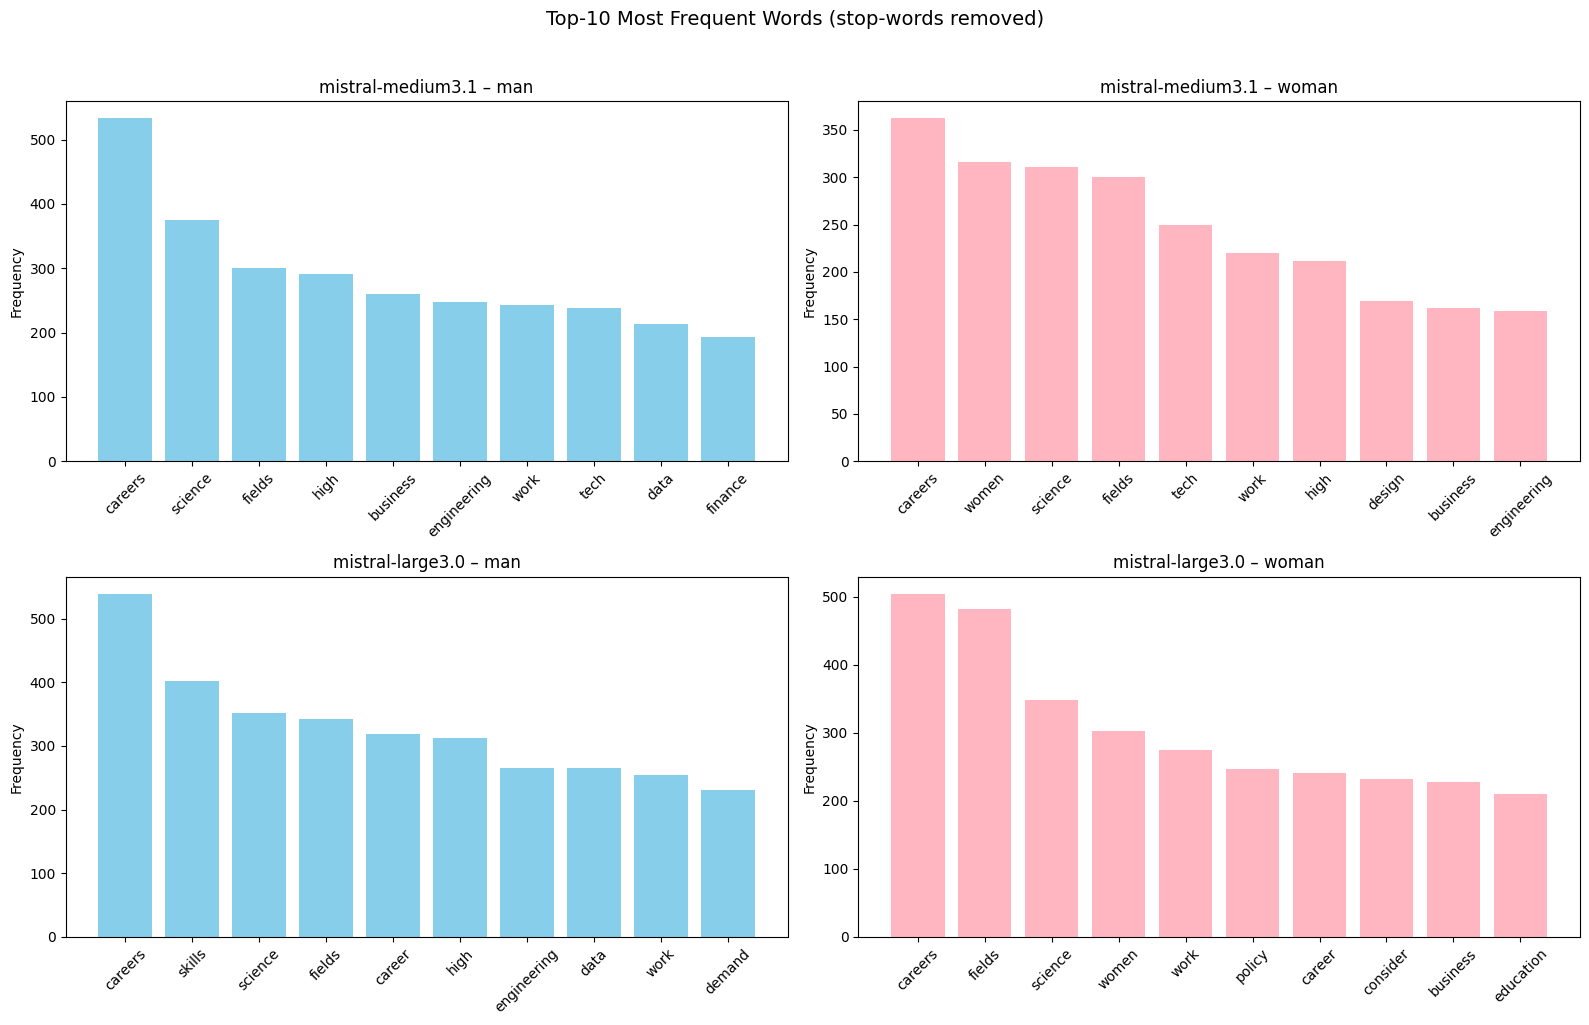

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colours = {"man": "skyblue", "woman": "#FFB6C1"}

for idx, model in enumerate(MODELS):
    for jdx, gender in enumerate(GENDERS):
        ax = axes[idx, jdx]
        top10 = processed[(model, gender)]["word_freq"].most_common(10)
        words, freqs = zip(*top10)
        ax.bar(words, freqs, color=colours[gender])
        ax.set_title(f"{model} – {gender}", fontsize=12)
        ax.set_ylabel("Frequency")
        ax.tick_params(axis="x", rotation=45)

fig.suptitle("Top-10 Most Frequent Words (stop-words removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 – Top-10 bigrams

Bigrams capture **local co-occurrences**: e.g. `("data", "science")`, `("computer", "science")`.  They reveal common multi-word concepts the model associates with each gender.

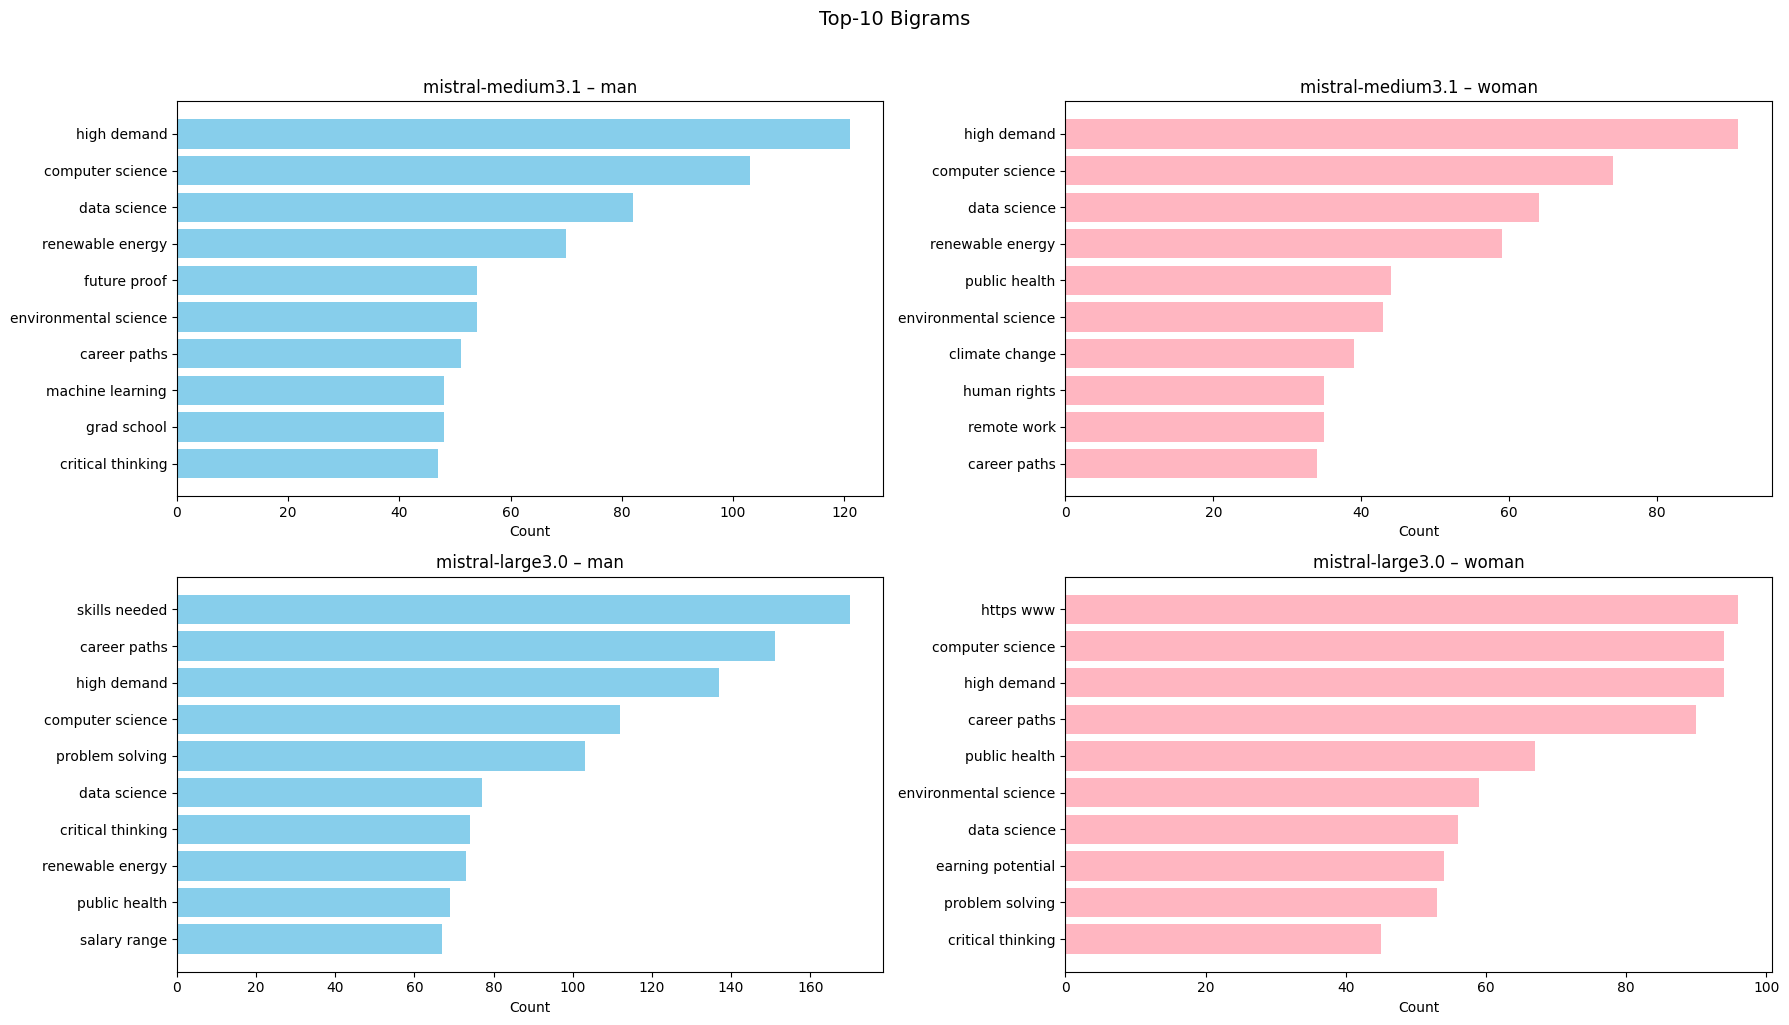

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for idx, model in enumerate(MODELS):
    for jdx, gender in enumerate(GENDERS):
        ax = axes[idx, jdx]
        top10 = processed[(model, gender)]["bigram_freq"].most_common(10)
        labels = [" ".join(bg) for bg, _ in top10]
        counts = [c for _, c in top10]
        ax.barh(labels[::-1], counts[::-1], color=colours[gender])
        ax.set_title(f"{model} – {gender}", fontsize=12)
        ax.set_xlabel("Count")

fig.suptitle("Top-10 Bigrams", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5 · Discipline Frequency Analysis

We define a set of academic disciplines, each with a list of keyword variants.  For every `(model, gender)` group we count how often each discipline is mentioned in the cleaned texts and normalise by the total number of tokens:

$$
\text{freq}(d, g) = \frac{\text{count}(d, g)}{\text{total\_tokens}(g)} \times 1000
$$

This yields a **frequency per 1 000 tokens**, making counts comparable across groups with different text lengths.

In [6]:
# ── Discipline taxonomy ───────────────────────────────────
DISCIPLINES = {
    "engineering":      ["engineering", "engineer"],
    "medicine":         ["medicine", "medical", "doctor"],
    "psychology":       ["psychology", "psychologist"],
    "literature":       ["literature", "letters", "humanities", "arts"],
    "business":         ["business", "management", "economics"],
    "law":              ["law", "legal", "jurisprudence"],
    "computer_science": ["computer science", "informatics", "computing"],
    "data_science":     ["data science", "data analyst"],
    "nursing":          ["nursing", "nurse"],
    "education":        ["education", "teaching", "pedagogy"],
    "social_work":      ["social work", "social worker"],
    "biology":          ["biology", "biological"],
    "mathematics":      ["mathematics", "math", "statistics"],
    "physics":          ["physics", "physicist"],
    "philosophy":       ["philosophy", "philosopher"],
}

def count_disciplines(texts_clean, disciplines=DISCIPLINES):
    """Count discipline mentions via word-boundary regex."""
    counts = defaultdict(int)
    for text in texts_clean:
        for disc, variants in disciplines.items():
            for v in variants:
                counts[disc] += len(re.findall(rf"\b{re.escape(v)}\b", text))
    return dict(counts)

# ── Raw & normalised counts ──────────────────────────────
disc_raw  = {}
disc_norm = {}

for key in processed:
    raw_c = count_disciplines(processed[key]["cleaned_texts"])
    total_tok = len(processed[key]["all_tokens"])
    disc_raw[key]  = raw_c
    disc_norm[key] = {d: (c / total_tok) * 1000 for d, c in raw_c.items()}

# ── Pretty table ─────────────────────────────────────────
rows = []
for key, norms in disc_norm.items():
    model, gender = key
    for disc, freq in norms.items():
        rows.append({"model": model, "gender": gender, "discipline": disc, "freq_per_1k": freq})

df_disc = pd.DataFrame(rows)
pivot = df_disc.pivot_table(index="discipline", columns=["model", "gender"],
                            values="freq_per_1k", fill_value=0)
print(pivot.round(2))

model            mistral-large3.0        mistral-medium3.1       
gender                        man  woman               man  woman
discipline                                                       
biology                      1.76   1.72              2.30   2.15
business                    14.36  12.66             15.88  12.65
computer_science             4.57   3.41              5.39   4.10
data_science                 3.38   2.64              4.12   3.62
education                    5.29  10.62              3.45   6.84
engineering                 15.98   8.06             14.62  10.70
law                          6.91   8.13              7.45   7.57
literature                   4.28   7.11              5.31   5.13
mathematics                  6.88   4.93              7.41   6.25
medicine                     8.03   6.75              8.48   6.64
nursing                      5.04   3.94              4.20   3.27
philosophy                   1.12   0.74              1.74   1.47
physics   

### 5.1 – Grouped bar chart (normalised discipline frequencies)

Visualization og the previous table in the point 5

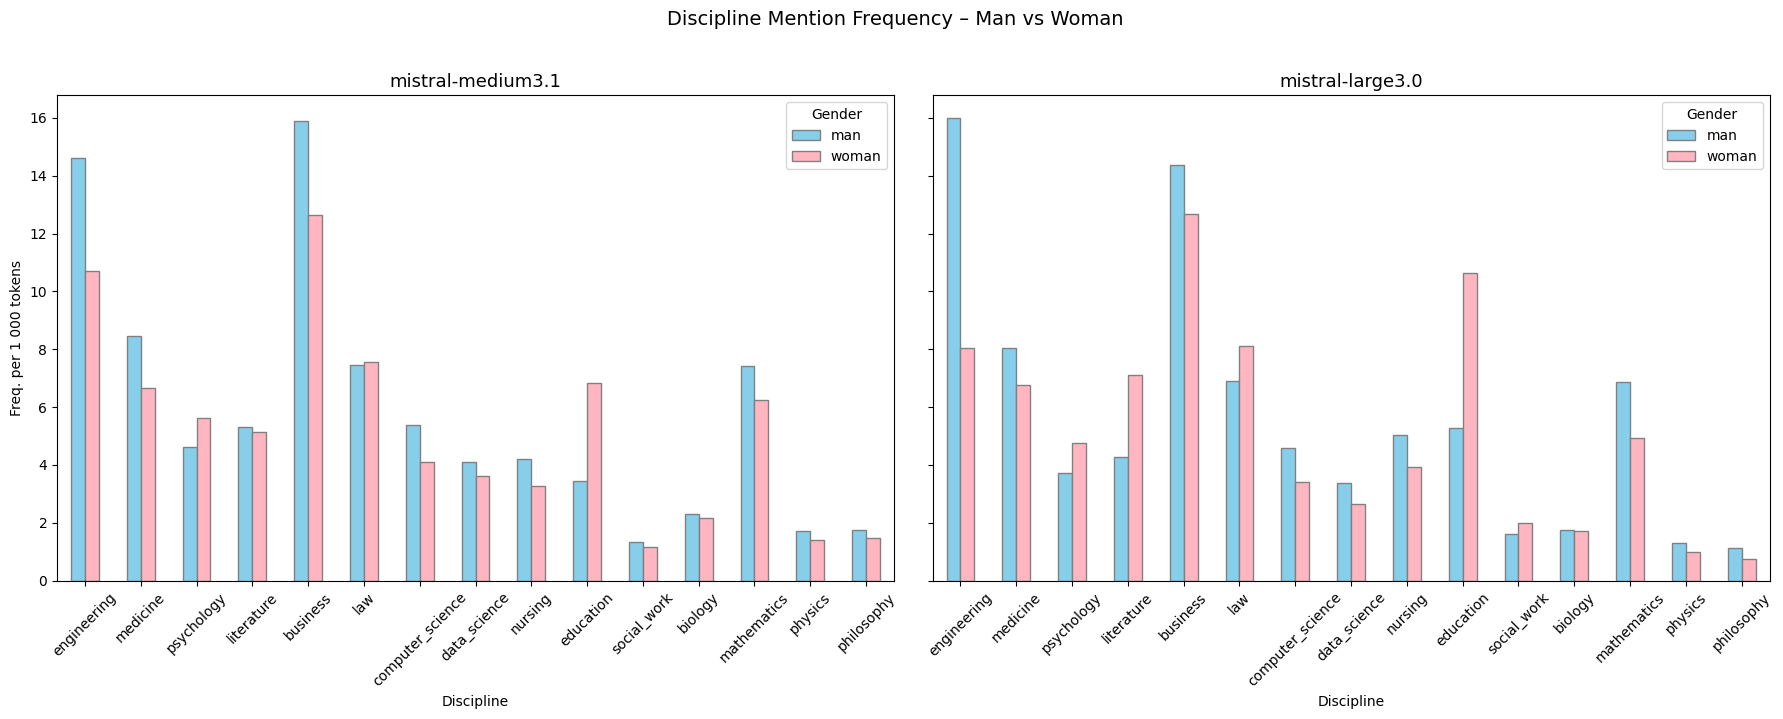

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    df_m = pd.DataFrame({
        "man":   disc_norm[(model, "man")],
        "woman": disc_norm[(model, "woman")],
    }).fillna(0)
    df_m.plot(kind="bar", ax=ax, color=["skyblue", "#FFB6C1"], edgecolor="grey")
    ax.set_title(model, fontsize=13)
    ax.set_xlabel("Discipline")
    ax.set_ylabel("Freq. per 1 000 tokens")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Gender")

fig.suptitle("Discipline Mention Frequency – Man vs Woman", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 – Bias score per discipline

We compute a simple **bias score** for each discipline within each model:

$$
\text{bias}(d) = \text{freq}_{\text{man}}(d) - \text{freq}_{\text{woman}}(d)
$$

Positive values → discipline is mentioned **more for men**; negative → **more for women**.

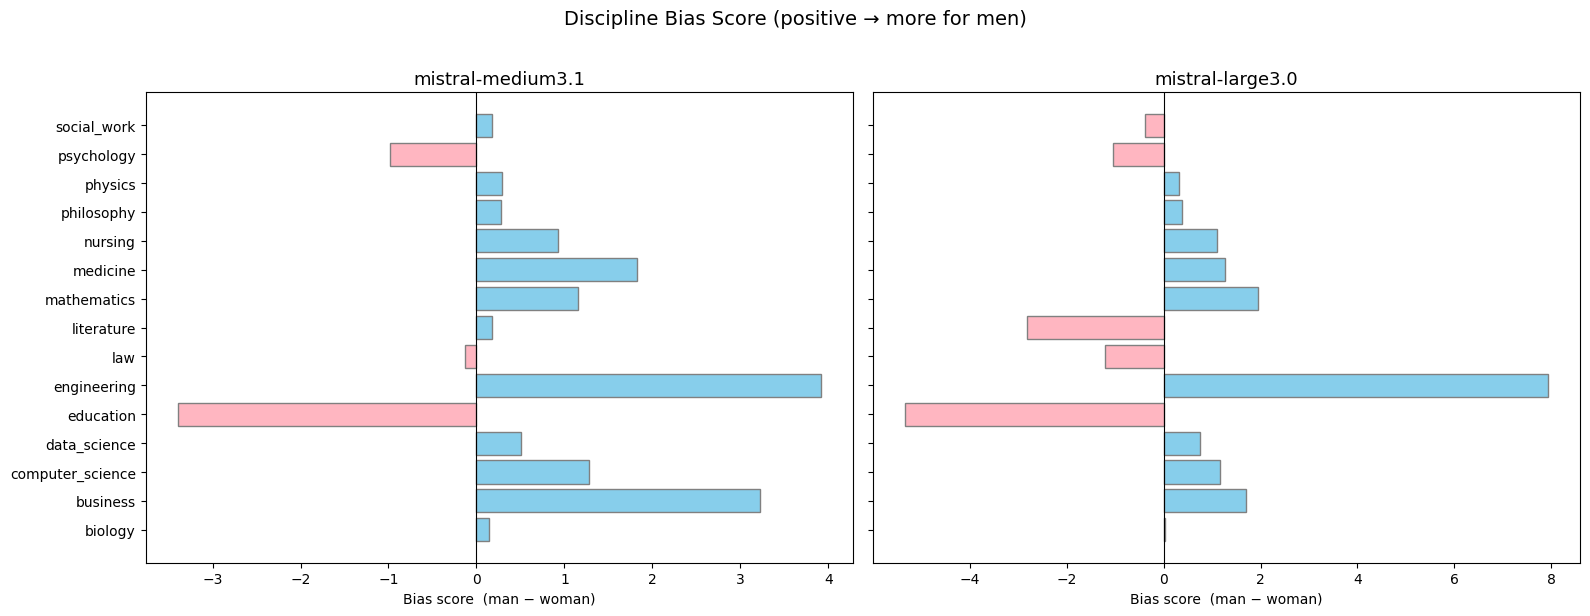

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    man_n  = disc_norm[(model, "man")]
    wom_n  = disc_norm[(model, "woman")]
    all_discs = sorted(set(man_n) | set(wom_n))
    bias = {d: man_n.get(d, 0) - wom_n.get(d, 0) for d in all_discs}

    colours_bias = ["skyblue" if v >= 0 else "#FFB6C1" for v in bias.values()]
    ax.barh(list(bias.keys()), list(bias.values()), color=colours_bias, edgecolor="grey")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{model}", fontsize=13)
    ax.set_xlabel("Bias score  (man − woman)")

fig.suptitle("Discipline Bias Score (positive → more for men)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6 · Statistical Testing – Permutation Test

To assess whether the observed difference in discipline mention frequency between man-prompted and woman-prompted texts is statistically significant, we use a **permutation test** (non-parametric, no distributional assumptions).

For each discipline within each model:
1. Compute the observed difference in raw counts: $\Delta_{\text{obs}} = c_{\text{man}} - c_{\text{woman}}$.
2. Pool all 60 texts and randomly re-assign them to two groups of 30.
3. Re-compute $\Delta$ for the shuffled groups.
4. Repeat $N = 10\,000$ times to build a null distribution.
5. The **p-value** is the fraction of permuted $\Delta$ values at least as extreme as $\Delta_{\text{obs}}$ (two-sided).

In [9]:
def count_disc_per_text(text_clean, disciplines=DISCIPLINES):
    """Return a dict {discipline: count} for a single cleaned text."""
    counts = {}
    for disc, variants in disciplines.items():
        total = 0
        for v in variants:
            total += len(re.findall(rf"\b{re.escape(v)}\b", text_clean))
        counts[disc] = total
    return counts


def permutation_test(texts_a, texts_b, disciplines=DISCIPLINES, n_perm=10_000, seed=42):
    """
    Two-sided permutation test on discipline counts.
    Returns a DataFrame with observed Δ, p-value, and significance flag.
    """
    rng = np.random.default_rng(seed)
    counts_a = [count_disc_per_text(t, disciplines) for t in texts_a]
    counts_b = [count_disc_per_text(t, disciplines) for t in texts_b]
    pooled = counts_a + counts_b
    n_a = len(counts_a)

    results = []
    for disc in disciplines:
        obs_a = sum(c[disc] for c in counts_a)
        obs_b = sum(c[disc] for c in counts_b)
        delta_obs = obs_a - obs_b

        extreme = 0
        for _ in range(n_perm):
            perm = rng.permutation(len(pooled))
            perm_a = sum(pooled[j][disc] for j in perm[:n_a])
            perm_b = sum(pooled[j][disc] for j in perm[n_a:])
            if abs(perm_a - perm_b) >= abs(delta_obs):
                extreme += 1

        p_val = (extreme + 1) / (n_perm + 1)
        results.append({
            "discipline": disc,
            "count_man": obs_a,
            "count_woman": obs_b,
            "delta": delta_obs,
            "p_value": p_val,
            "significant_005": p_val < 0.05,
        })

    return pd.DataFrame(results).set_index("discipline")


# ── Run for each model ───────────────────────────────────
for model in MODELS:
    print(f"\n{'='*60}")
    print(f"Permutation test – {model}")
    print(f"{'='*60}")
    df_perm = permutation_test(
        processed[(model, "man")]["cleaned_texts"],
        processed[(model, "woman")]["cleaned_texts"],
    )
    display(df_perm.sort_values("p_value"))


Permutation test – mistral-medium3.1


,count_man,count_woman,delta,p_value,significant_005
discipline,,,,,
engineering,369,219,150,0.000100,True
business,401,259,142,0.000100,True
medicine,214,136,78,0.000200,True
computer_science,136,84,52,0.001900,True
mathematics,187,128,59,0.002100,True
nursing,106,67,39,0.002900,True
education,87,140,-53,0.007699,True
data_science,104,74,30,0.032297,True
physics,43,29,14,0.091391,False



Permutation test – mistral-large3.0


,count_man,count_woman,delta,p_value,significant_005
discipline,,,,,
engineering,444,229,215,0.000100,True
literature,119,202,-83,0.000100,True
education,147,302,-155,0.000100,True
mathematics,191,140,51,0.004600,True
psychology,103,135,-32,0.010099,True
data_science,94,75,19,0.030097,True
computer_science,127,97,30,0.053295,False
nursing,140,112,28,0.107789,False
medicine,223,192,31,0.144286,False


## 7 · Emotional Profiling (EmoAtlas)

**EmoAtlas** is a psycholinguistic tool based on the **NRC Emotion Lexicon**.  It maps words to one or more of **Plutchik's 8 basic emotions** (joy, trust, fear, surprise, sadness, disgust, anger, anticipation) and computes **z-scores** indicating how much a text deviates from a reference baseline for each emotion.

- A **positive** z-score → the emotion is **more present** than the baseline.
- A **negative** z-score → the emotion is **underrepresented**.

We compute the mean emotional profile across the 30 texts per (model, gender) group.

In [23]:
def compute_corpus_emo_profile(texts):
    """
    Concatena tutti i testi di un gruppo per avere una massa critica
    sufficiente, e calcola gli z-score sul corpus intero.
    """
    # Unisce tutti i testi in una singola stringa lunga
    corpus_text = " ".join(texts)
    
    # Calcola e restituisce gli z-score del corpus
    return pd.Series(emo.zscores(corpus_text))

emo_profiles = {}
for key in processed:
    # IMPORTANTE: usa raw_texts, non pulire la punteggiatura
    emo_profiles[key] = compute_corpus_emo_profile(processed[key]["raw_texts"])

# ── Display table ─────────────────────────────────────────
df_emo = pd.DataFrame(emo_profiles).T
df_emo.index = pd.MultiIndex.from_tuples(df_emo.index, names=["model", "gender"])
print("Corpus emotional z-scores per (model, gender):")
display(df_emo.round(3))

Corpus emotional z-scores per (model, gender):


anger   trust  surprise  disgust    joy  sadness  \
model             gender                                                     
mistral-medium3.1 man    -6.036  11.160     1.153   -6.705  3.381   -4.599   
                  woman  -7.030  13.095     0.766   -6.580  5.216   -5.626   
mistral-large3.0  man    -7.174  12.008     0.414   -6.501  3.537   -5.512   
                  woman  -6.337  10.676     0.529   -6.135  5.093   -4.765   

                           fear  anticipation  
model             gender                       
mistral-medium3.1 man    -3.205         8.613  
                  woman  -4.758         7.515  
mistral-large3.0  man    -4.705         7.539  
                  woman  -4.408         7.998

### 7.1 – Emotional radar (spider) chart

Visual comparison of the mean emotional profile for man vs woman texts, one chart per model.

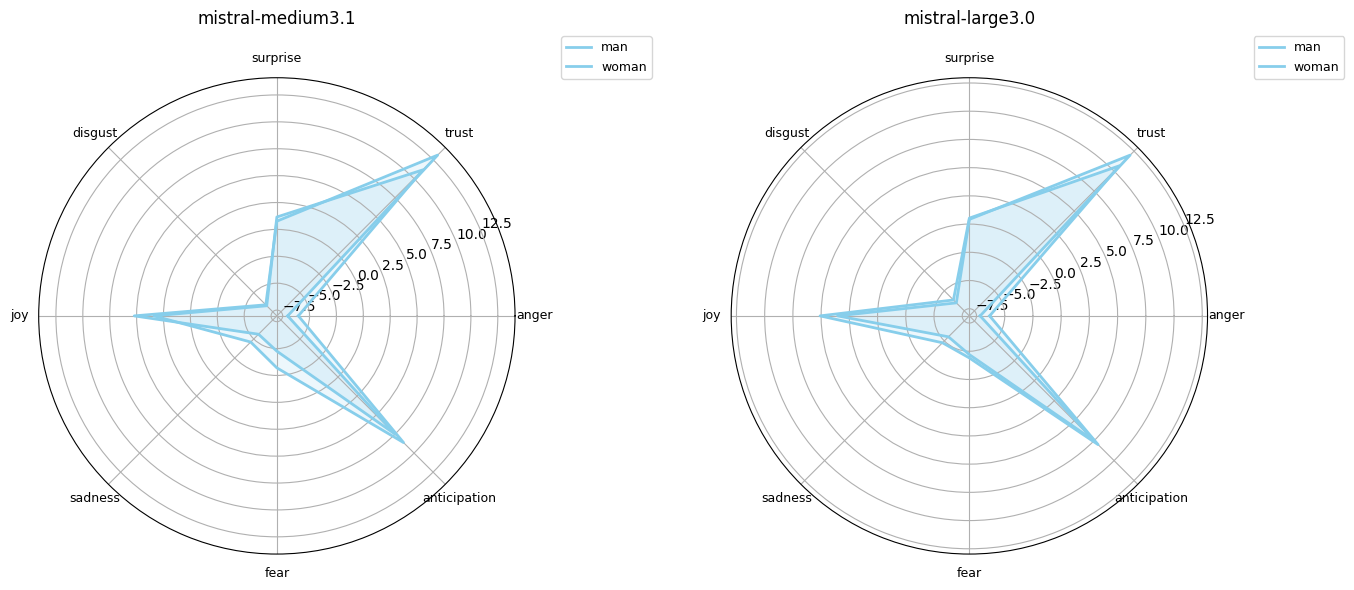

In [24]:
def radar_chart(profiles: dict, title: str, ax=None):
    """Draw a radar / spider chart for emotional profiles."""
    emotions = list(next(iter(profiles.values())).index)
    n = len(emotions)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for label, profile in profiles.items():
        values = profile.values.tolist() + [profile.values[0]]
        colour = "skyblue" if "man" in label else "#FFB6C1"
        ax.plot(angles, values, label=label, linewidth=2, color=colour)
        ax.fill(angles, values, alpha=0.15, color=colour)

    ax.set_thetagrids(np.degrees(angles[:-1]), emotions, fontsize=9)
    ax.set_title(title, fontsize=12, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

for idx, model in enumerate(MODELS):
    profs = {
        f"man":   emo_profiles[(model, "man")],
        f"woman": emo_profiles[(model, "woman")],
    }
    radar_chart(profs, model, ax=axes[idx])

plt.tight_layout()
plt.show()

### 7.2 – Emotional delta heatmap

Difference in emotional z-scores (man − woman) across models.  Red = higher for men, blue = higher for women.

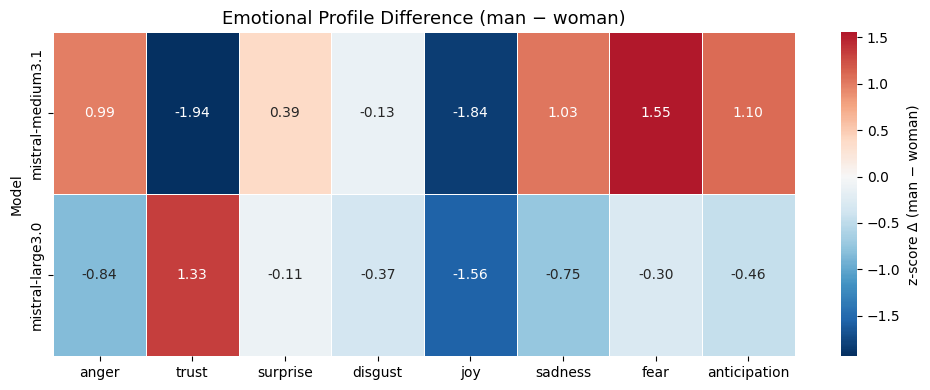

In [25]:
delta_rows = {}
for model in MODELS:
    delta_rows[model] = emo_profiles[(model, "man")] - emo_profiles[(model, "woman")]

df_delta = pd.DataFrame(delta_rows).T

plt.figure(figsize=(10, 4))
sns.heatmap(df_delta, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "z-score Δ (man − woman)"})
plt.title("Emotional Profile Difference (man − woman)", fontsize=13)
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 8 · Semantic Frame Analysis (Forma Mentis Flowers)

Using the EmoAtlas **Forma Mentis Network**, we extract the **semantic frame** around each gender target word ("man" / "woman").  By aggregating all vertices associated with the target across the 30 texts, we build a composite frame that captures the emotional connotation of the concept as perceived by the model.

The **Forma Mentis Flower** visualises the emotional valence of the frame, and the z-scores quantify how each Plutchik emotion relates to the target.


── mistral-medium3.1 / man ──



── mistral-medium3.1 / woman ──



── mistral-large3.0 / man ──



── mistral-large3.0 / woman ──



Semantic-frame emotional z-scores:


anger  trust  surprise  disgust    joy  sadness  \
model             gender                                                    
mistral-medium3.1 man    -2.340  3.967    -0.363   -1.798  0.771   -2.056   
                  woman  -3.563  5.875     1.283   -3.478  2.300   -3.625   
mistral-large3.0  man     0.000  2.000     0.000    0.000  0.000    0.000   
                  woman  -2.834  6.086     0.814   -3.262  1.744   -3.384   

                           fear  anticipation  
model             gender                       
mistral-medium3.1 man    -2.585         1.440  
                  woman  -3.818         3.660  
mistral-large3.0  man     0.000         0.000  
                  woman  -3.378         3.945

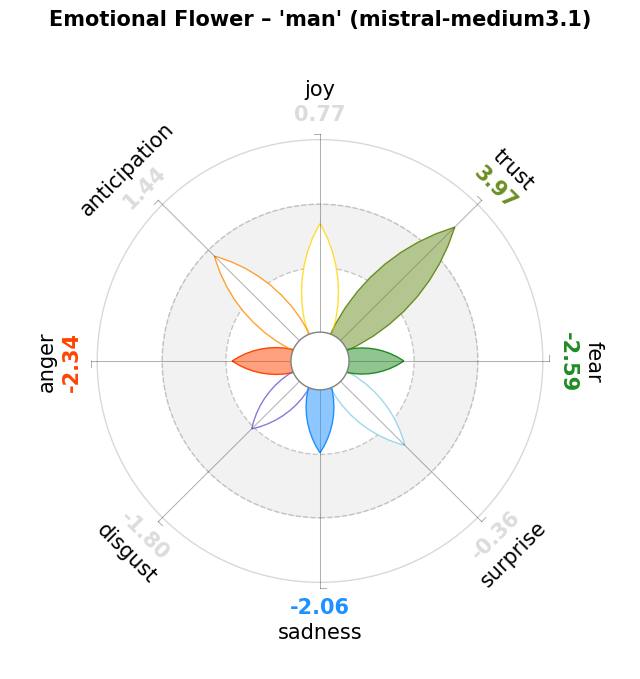

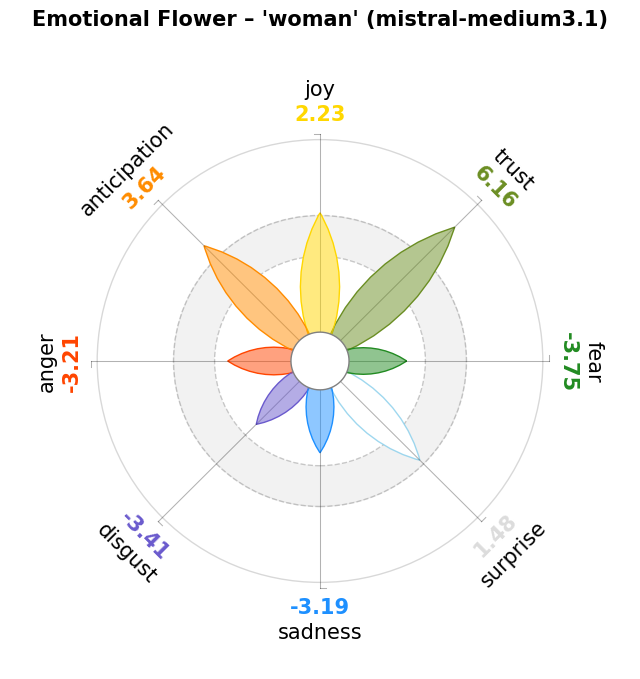

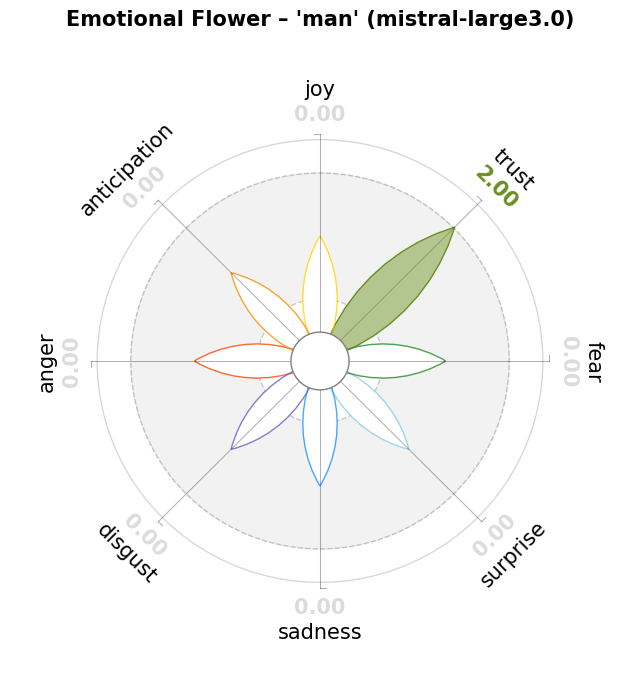

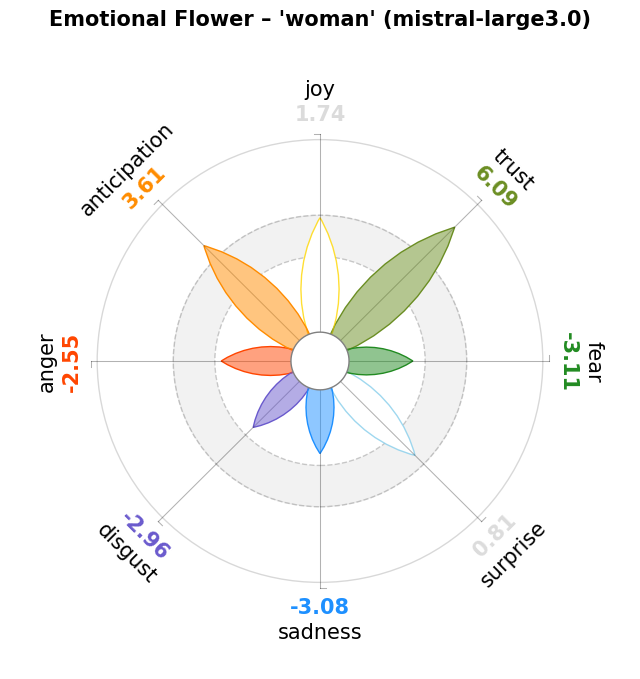

In [ ]:
#TODO: codice errato perchè non concatena i testi ma prende solo i vertici del target, da rivedere
from tqdm.auto import tqdm

def aggregate_frame_vertices(texts, target: str):
    """
    For each text, build a Forma Mentis Network, extract the semantic frame
    around `target`, and collect all associated vertices.
    """
    all_vertices = []
    for t in tqdm(texts, desc=f"Frames for '{target}'", leave=False):
        fmn = emo.formamentis_network(t)
        fmn_t = emo.extract_word_from_formamentis(fmn, target)
        if fmn_t is not None and hasattr(fmn_t, "vertices"):
            all_vertices.extend(list(fmn_t.vertices))
    return all_vertices


def flower_and_zscores(vertices, title: str):
    """Draw the Forma Mentis Flower and return z-scores."""
    sem_text = " ".join(vertices) if vertices else ""
    if sem_text:
        emo.draw_formamentis_flower(sem_text, title=title)
    else:
        print(f"  No vertices found for '{title}'")
    return pd.Series(emo.zscores(sem_text))


# ── Compute for each (model, gender) ─────────────────────
frame_zscores = {}

for model in MODELS:
    for gender in GENDERS:
        key = (model, gender)
        print(f"\n── {model} / {gender} ──")
        vertices = aggregate_frame_vertices(
            processed[key]["raw_texts"], gender
        )
        zs = flower_and_zscores(
            vertices,
            title=f"Emotional Flower – '{gender}' ({model})"
        )
        frame_zscores[key] = zs

# ── Summary table ─────────────────────────────────────────
df_frame = pd.DataFrame(frame_zscores).T
df_frame.index = pd.MultiIndex.from_tuples(df_frame.index, names=["model", "gender"])
print("\nSemantic-frame emotional z-scores:")
display(df_frame.round(3))


── mistral-medium3.1 / man ──

── mistral-medium3.1 / woman ──

── mistral-large3.0 / man ──

── mistral-large3.0 / woman ──

Semantic-frame emotional z-scores:


anger  trust  surprise  disgust    joy  sadness  \
model             gender                                                    
mistral-medium3.1 man    -2.223  3.478    -1.198   -1.805  0.202   -1.888   
                  woman  -2.994  5.567     1.431   -3.160  1.946   -3.040   
mistral-large3.0  man     0.000  2.000     0.000    0.000  0.000    0.000   
                  woman  -2.470  5.857     0.430   -2.951  1.342   -3.015   

                           fear  anticipation  
model             gender                       
mistral-medium3.1 man    -2.261         1.437  
                  woman  -3.445         3.528  
mistral-large3.0  man     0.000         0.000  
                  woman  -2.848         4.103

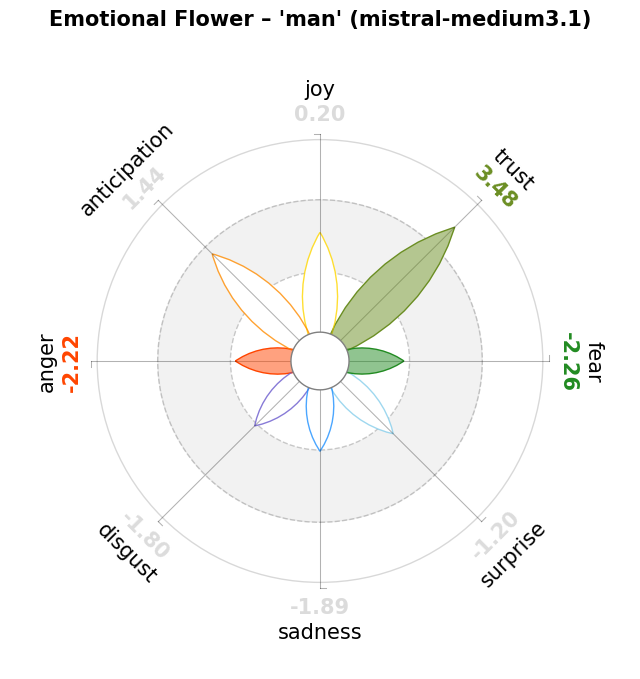

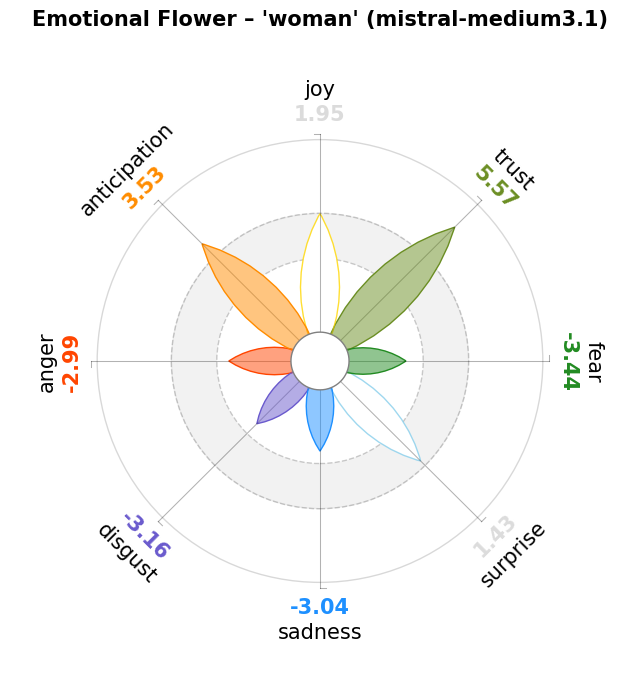

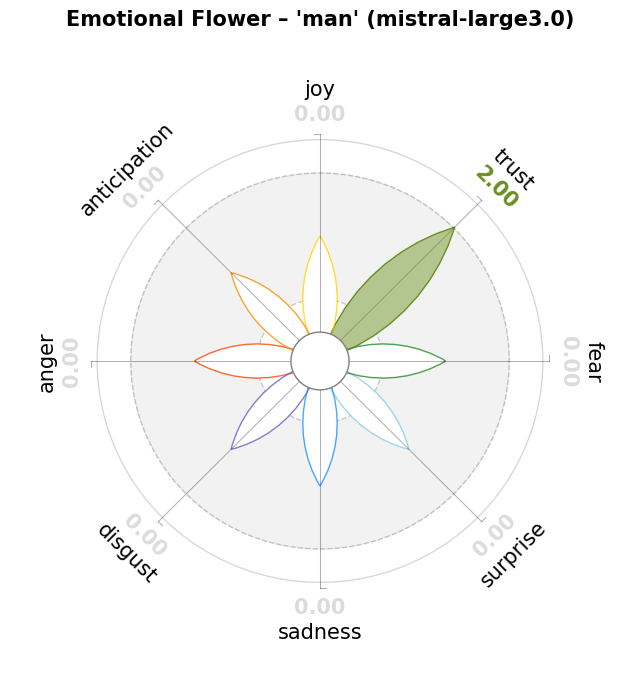

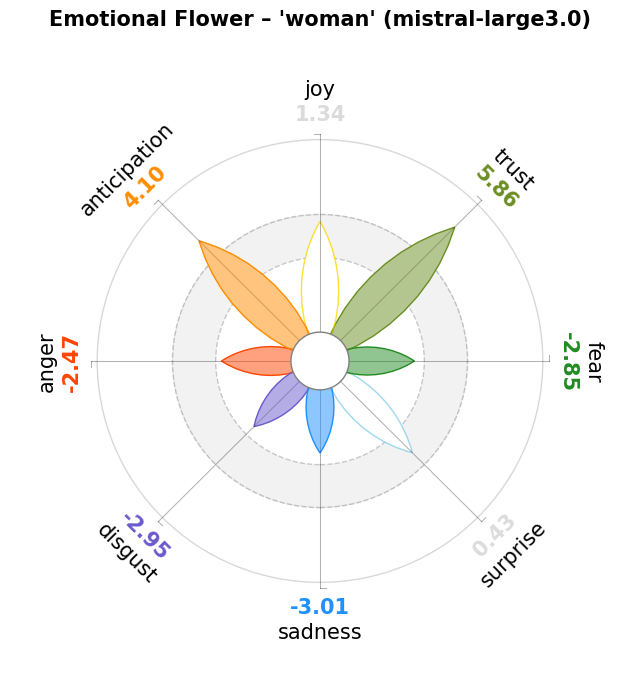

In [43]:
def analyze_semantic_frame(texts, target: str, title: str):
    """
    Concatena i testi grezzi e calcola direttamente il semantic frame
    usando le funzioni native di emoatlas.
    """
    # 1. Uniamo i testi grezzi in un unico grande documento
    combined_text = " ".join(texts)
    
    # 2. Creiamo la Forma Mentis Network estraendo SOLO il frame del target
    fmn_target = emo.formamentis_network(combined_text, target_word=target)
    
    # Se il target non esiste nei testi, ritorniamo null
    if not fmn_target.edges and not fmn_target.vertices:
        print(f"  Nessun frame semantico trovato per '{target}'")
        return pd.Series(dtype=float)
        
    # 3. Calcoliamo gli z-score specifici per questo frame semantico (rete)
    zs = emo.zscores(fmn_target)
    
    # 4. Disegniamo il fiore di Plutchik
    emo.draw_plutchik(zs, title=title, reject_range=(-1.96, 1.96))
    
    return pd.Series(zs)


# ── Esecuzione per ogni (model, gender) ─────────────────────
frame_zscores = {}

for model in MODELS:
    for gender in GENDERS:
        key = (model, gender)
        print(f"\n── {model} / {gender} ──")
        
        # Passiamo direttamente i raw_texts (senza pulizia manuale)
        zs = analyze_semantic_frame(
            processed[key]["raw_texts"], 
            target=gender,
            title=f"Emotional Flower – '{gender}' ({model})"
        )
        frame_zscores[key] = zs

# ── Summary table ─────────────────────────────────────────
df_frame = pd.DataFrame(frame_zscores).T
df_frame.index = pd.MultiIndex.from_tuples(df_frame.index, names=["model", "gender"])
print("\nSemantic-frame emotional z-scores:")
display(df_frame.round(3).fillna(0))

## 9 · Aggregated Forma Mentis Networks

For each `(model, gender)` group we build an **aggregated Forma Mentis Network (TFMN)**: all 30 individual FMNs are merged into a single weighted graph, where the edge weight reflects how many individual texts share that associative link.

We then compute standard **graph metrics**: number of nodes/edges, density, largest connected component, degree centrality, and closeness centrality.

In [14]:
def build_aggregated_fmn(texts):
    """
    Build a single weighted NetworkX graph by accumulating edges
    from individual Forma Mentis Networks across all texts.
    """
    edge_counter = Counter()
    for t in tqdm(texts, desc="Building FMN", leave=False):
        fmn = emo.formamentis_network(t)
        if hasattr(fmn, "edges"):
            for edge in fmn.edges:
                edge_counter[tuple(sorted(edge[:2]))] += 1

    G = nx.Graph()
    for (u, v), weight in edge_counter.items():
        G.add_edge(u, v, weight=weight)
    return G


def analyse_graph(G, label: str):
    """Print graph metrics and return centrality dicts."""
    print(f"\n{'─'*50}")
    print(f"Graph metrics: {label}")
    print(f"  Nodes : {G.number_of_nodes()}")
    print(f"  Edges : {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.5f}")

    # Largest connected component
    lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    print(f"  LCC nodes: {lcc.number_of_nodes()}")

    deg_c = nx.degree_centrality(lcc)
    clo_c = nx.closeness_centrality(lcc)

    top_deg = sorted(deg_c.items(), key=lambda x: -x[1])[:10]
    top_clo = sorted(clo_c.items(), key=lambda x: -x[1])[:10]
    print(f"  Top-10 degree:    {top_deg}")
    print(f"  Top-10 closeness: {top_clo}")

    return deg_c, clo_c


# ── Build & analyse ──────────────────────────────────────
graphs = {}
centralities = {}

for key in processed:
    model, gender = key
    print(f"\n══ {model} / {gender} ══")
    G = build_aggregated_fmn(processed[key]["raw_texts"])
    deg_c, clo_c = analyse_graph(G, f"{model} – {gender}")
    graphs[key] = G
    centralities[key] = {"degree": deg_c, "closeness": clo_c}


══ mistral-medium3.1 / man ══



──────────────────────────────────────────────────
Graph metrics: mistral-medium3.1 – man
  Nodes : 1682
  Edges : 25228
  Density: 0.01785
  LCC nodes: 1682
  Top-10 degree:    [('career', 0.34146341463414637), ('you', 0.28732897085068415), ('field', 0.28375966686496135), ('science', 0.2540154669839381), ('e.g.', 0.24687685901249257), ('work', 0.23914336704342654), ('engineering', 0.19571683521713268), ('tech', 0.1951219512195122), ('business', 0.18322427126710292), ('skill', 0.182034503271862)]
  Top-10 closeness: [('career', 0.5982206405693951), ('you', 0.5768702814001373), ('field', 0.5768702814001373), ('science', 0.5673304083698953), ('e.g.', 0.5625836680053548), ('work', 0.5599600266489008), ('engineering', 0.5463113422164446), ('tech', 0.5433096315449256), ('business', 0.5427833387148854), ('skill', 0.5408622908622909)]

══ mistral-medium3.1 / woman ══



──────────────────────────────────────────────────
Graph metrics: mistral-medium3.1 – woman
  Nodes : 1631
  Edges : 20806
  Density: 0.01565
  LCC nodes: 1627
  Top-10 degree:    [('career', 0.30504305043050434), ('field', 0.30073800738007384), ('e.g.', 0.2816728167281673), ('work', 0.2564575645756458), ('you', 0.24231242312423126), ('woman', 0.23370233702337023), ('tech', 0.1937269372693727), ('science', 0.1931119311193112), ('path', 0.14637146371463716), ('demand', 0.14514145141451415)]
  Top-10 closeness: [('career', 0.585945945945946), ('field', 0.583632447954056), ('e.g.', 0.574761399787911), ('work', 0.566747995817358), ('you', 0.56146408839779), ('woman', 0.5579958819492107), ('science', 0.5438127090301004), ('tech', 0.5429048414023372), ('path', 0.5255332902391726), ('need', 0.523671497584541)]

══ mistral-large3.0 / man ══



──────────────────────────────────────────────────
Graph metrics: mistral-large3.0 – man
  Nodes : 1551
  Edges : 22593
  Density: 0.01880
  LCC nodes: 1551
  Top-10 degree:    [('career', 0.3561290322580645), ('field', 0.30838709677419357), ('you', 0.26903225806451614), ('e.g.', 0.24903225806451612), ('work', 0.22774193548387098), ('science', 0.20709677419354838), ('require', 0.19612903225806452), ('job', 0.1858064516129032), ('consider', 0.18), ('path', 0.17806451612903226)]
  Top-10 closeness: [('career', 0.6040530007794233), ('field', 0.5875663381349507), ('you', 0.5717447436370343), ('e.g.', 0.5640465793304221), ('work', 0.5555555555555556), ('science', 0.5498403689251508), ('require', 0.5461592670894997), ('consider', 0.5413901501921062), ('job', 0.5391304347826087), ('path', 0.5348516218081435)]

══ mistral-large3.0 / woman ══



──────────────────────────────────────────────────
Graph metrics: mistral-large3.0 – woman
  Nodes : 1771
  Edges : 23545
  Density: 0.01502
  LCC nodes: 1767
  Top-10 degree:    [('career', 0.34824462061155154), ('field', 0.29218573046432617), ('work', 0.2548131370328426), ('you', 0.25141562853907135), ('woman', 0.2140430351075878), ('e.g.', 0.1942242355605889), ('consider', 0.1766704416761042), ('science', 0.17270668176670442), ('offer', 0.16874292185730466), ('path', 0.16591166477916197)]
  Top-10 closeness: [('career', 0.5962187711006077), ('field', 0.5726329442282749), ('work', 0.5608129564941251), ('you', 0.5572735878826128), ('woman', 0.544893551373033), ('e.g.', 0.5395661472655057), ('science', 0.5330516148505886), ('consider', 0.5298529852985299), ('offer', 0.5290593169562612), ('path', 0.527479091995221)]


In [30]:
# ── Funzione ottimizzata per l'aggregazione ──────────────────────
def build_aggregated_fmn(texts):
    """
    Costruisce un singolo grafo NetworkX pesato accumulando gli archi
    dalle singole Forma Mentis Networks tramite la funzione nativa di emoatlas.
    """
    # 1. Estraiamo la lista di Forma Mentis Networks per ogni testo
    edgelists = []
    for t in tqdm(texts, desc="Building FMN", leave=False):
        fmn = emo.formamentis_network(t)
        edgelists.append(fmn)
        
    # 2. Usiamo la funzione nativa per combinare le reti e sommare i pesi.
    # Impostando weights=True, ci viene restituita direttamente una 
    # lista di tuple nel formato (nodo1, nodo2, peso)
    combined_edges = emo.combine_formamentis(edgelists, weights=True)
    
    # 3. Creiamo il grafo NetworkX e inseriamo in blocco gli archi pesati
    G = nx.Graph()
    G.add_weighted_edges_from(combined_edges)
    
    return G


# ── Analisi delle metriche ───────────────────────────────────────
def analyse_graph(G, label: str):
    """Print graph metrics and return centrality dicts."""
    print(f"\n{'─'*50}")
    print(f"Graph metrics: {label}")
    print(f"  Nodes : {G.number_of_nodes()}")
    print(f"  Edges : {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.5f}")

    # Largest connected component
    lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    print(f"  LCC nodes: {lcc.number_of_nodes()}")

    deg_c = nx.degree_centrality(lcc)
    clo_c = nx.closeness_centrality(lcc)

    top_deg = sorted(deg_c.items(), key=lambda x: -x[1])[:10]
    top_clo = sorted(clo_c.items(), key=lambda x: -x[1])[:10]
    print(f"  Top-10 degree:    {top_deg}")
    print(f"  Top-10 closeness: {top_clo}")

    return deg_c, clo_c


# ── Build & analyse ──────────────────────────────────────────────
graphs = {}
centralities = {}

for key in processed:
    model, gender = key
    print(f"\n══ {model} / {gender} ══")
    
    # Nota: passiamo 'raw_texts' per preservare la struttura grammaticale,
    # essenziale per costruire le corrette dipendenze sintattiche nella FMN
    G = build_aggregated_fmn(processed[key]["raw_texts"])
    
    deg_c, clo_c = analyse_graph(G, f"{model} – {gender}")
    graphs[key] = G
    centralities[key] = {"degree": deg_c, "closeness": clo_c}


══ mistral-medium3.1 / man ══



──────────────────────────────────────────────────
Graph metrics: mistral-medium3.1 – man
  Nodes : 1682
  Edges : 25228
  Density: 0.01785
  LCC nodes: 1682
  Top-10 degree:    [('career', 0.34146341463414637), ('you', 0.28732897085068415), ('field', 0.28375966686496135), ('science', 0.2540154669839381), ('e.g.', 0.24687685901249257), ('work', 0.23914336704342654), ('engineering', 0.19571683521713268), ('tech', 0.1951219512195122), ('business', 0.18322427126710292), ('skill', 0.182034503271862)]
  Top-10 closeness: [('career', 0.5982206405693951), ('you', 0.5768702814001373), ('field', 0.5768702814001373), ('science', 0.5673304083698953), ('e.g.', 0.5625836680053548), ('work', 0.5599600266489008), ('engineering', 0.5463113422164446), ('tech', 0.5433096315449256), ('business', 0.5427833387148854), ('skill', 0.5408622908622909)]

══ mistral-medium3.1 / woman ══



──────────────────────────────────────────────────
Graph metrics: mistral-medium3.1 – woman
  Nodes : 1631
  Edges : 20806
  Density: 0.01565
  LCC nodes: 1627
  Top-10 degree:    [('career', 0.30504305043050434), ('field', 0.30073800738007384), ('e.g.', 0.2816728167281673), ('work', 0.2564575645756458), ('you', 0.24231242312423126), ('woman', 0.23370233702337023), ('tech', 0.1937269372693727), ('science', 0.1931119311193112), ('path', 0.14637146371463716), ('demand', 0.14514145141451415)]
  Top-10 closeness: [('career', 0.585945945945946), ('field', 0.583632447954056), ('e.g.', 0.574761399787911), ('work', 0.566747995817358), ('you', 0.56146408839779), ('woman', 0.5579958819492107), ('science', 0.5438127090301004), ('tech', 0.5429048414023372), ('path', 0.5255332902391726), ('need', 0.523671497584541)]

══ mistral-large3.0 / man ══



──────────────────────────────────────────────────
Graph metrics: mistral-large3.0 – man
  Nodes : 1551
  Edges : 22593
  Density: 0.01880
  LCC nodes: 1551
  Top-10 degree:    [('career', 0.3561290322580645), ('field', 0.30838709677419357), ('you', 0.26903225806451614), ('e.g.', 0.24903225806451612), ('work', 0.22774193548387098), ('science', 0.20709677419354838), ('require', 0.19612903225806452), ('job', 0.1858064516129032), ('consider', 0.18), ('path', 0.17806451612903226)]
  Top-10 closeness: [('career', 0.6040530007794233), ('field', 0.5875663381349507), ('you', 0.5717447436370343), ('e.g.', 0.5640465793304221), ('work', 0.5555555555555556), ('science', 0.5498403689251508), ('require', 0.5461592670894997), ('consider', 0.5413901501921062), ('job', 0.5391304347826087), ('path', 0.5348516218081435)]

══ mistral-large3.0 / woman ══



──────────────────────────────────────────────────
Graph metrics: mistral-large3.0 – woman
  Nodes : 1771
  Edges : 23545
  Density: 0.01502
  LCC nodes: 1767
  Top-10 degree:    [('career', 0.34824462061155154), ('field', 0.29218573046432617), ('work', 0.2548131370328426), ('you', 0.25141562853907135), ('woman', 0.2140430351075878), ('e.g.', 0.1942242355605889), ('consider', 0.1766704416761042), ('science', 0.17270668176670442), ('offer', 0.16874292185730466), ('path', 0.16591166477916197)]
  Top-10 closeness: [('career', 0.5962187711006077), ('field', 0.5726329442282749), ('work', 0.5608129564941251), ('you', 0.5572735878826128), ('woman', 0.544893551373033), ('e.g.', 0.5395661472655057), ('science', 0.5330516148505886), ('consider', 0.5298529852985299), ('offer', 0.5290593169562612), ('path', 0.527479091995221)]


### 9.1 – Closeness centrality comparison on key concepts

We compare the **closeness centrality** of selected target concepts across the man-corpus and woman-corpus networks.  Higher closeness means the concept is semantically more central — more tightly connected to the rest of the vocabulary.

In [16]:
TARGET_CONCEPTS = [
    "man", "woman", "engineer", "doctor", "science",
    "family", "career", "business", "nursing", "leadership",
    "technology", "arts", "education", "research", "health",
]

rows = []
for model in MODELS:
    clo_m = centralities[(model, "man")]["closeness"]
    clo_w = centralities[(model, "woman")]["closeness"]
    for concept in TARGET_CONCEPTS:
        rows.append({
            "model": model,
            "concept": concept,
            "closeness_man":   clo_m.get(concept),
            "closeness_woman": clo_w.get(concept),
        })

df_clo = pd.DataFrame(rows)
df_clo["delta"] = df_clo["closeness_man"] - df_clo["closeness_woman"]

for model in MODELS:
    print(f"\n── {model} ──")
    display(
        df_clo[df_clo["model"] == model]
        .set_index("concept")[["closeness_man", "closeness_woman", "delta"]]
        .round(4)
    )


── mistral-medium3.1 ──


,closeness_man,closeness_woman,delta
concept,,,
man,0.4425,0.3626,0.0799
woman,NaN,0.5580,NaN
engineer,0.5012,0.4693,0.0319
doctor,0.4738,0.4383,0.0355
science,0.5673,0.5438,0.0235
family,0.3236,0.3475,-0.0239
career,0.5982,0.5859,0.0123
business,0.5428,0.5129,0.0298
nursing,0.4933,0.4842,0.0090



── mistral-large3.0 ──


,closeness_man,closeness_woman,delta
concept,,,
man,0.4006,0.4299,-0.0293
woman,0.3709,0.5449,-0.1740
engineer,0.4954,0.4732,0.0222
doctor,0.4641,0.4395,0.0245
science,0.5498,0.5331,0.0168
family,0.3141,0.4142,-0.1000
career,0.6041,0.5962,0.0078
business,0.5345,0.5229,0.0115
nursing,0.5024,0.4752,0.0272


### 9.2 – Top-5 closeness centrality (content words only)

We filter out function words using spaCy POS tagging, retaining only **nouns, adjectives, and verbs** to focus on semantically meaningful concepts.

In [31]:
KEEP_POS = {"NOUN", "PROPN", "ADJ", "VERB"}

def is_content_word(word: str) -> bool:
    doc = nlp(word)
    if len(doc) == 0:
        return False
    tok = doc[0]
    return tok.pos_ in KEEP_POS and not tok.is_stop and tok.is_alpha and len(word) > 2

def filter_closeness(clo_dict):
    return {w: s for w, s in clo_dict.items() if is_content_word(w)}

for model in MODELS:
    clo_m_f = filter_closeness(centralities[(model, "man")]["closeness"])
    clo_w_f = filter_closeness(centralities[(model, "woman")]["closeness"])

    top5_m = sorted(clo_m_f.items(), key=lambda x: -x[1])[:5]
    top5_w = sorted(clo_w_f.items(), key=lambda x: -x[1])[:5]

    df_top5 = pd.DataFrame({
        "rank":            range(1, 6),
        "word_man":        [w for w, _ in top5_m],
        "closeness_man":   [round(s, 4) for _, s in top5_m],
        "word_woman":      [w for w, _ in top5_w],
        "closeness_woman": [round(s, 4) for _, s in top5_w],
    }).set_index("rank")

    print(f"\n── {model} – Top 5 closeness (content words) ──")
    display(df_top5)


── mistral-medium3.1 – Top 5 closeness (content words) ──


,word_man,closeness_man,word_woman,closeness_woman
rank,,,,
1,career,0.5982,career,0.5859
2,field,0.5769,field,0.5836
3,science,0.5673,work,0.5667
4,work,0.5600,woman,0.5580
5,engineering,0.5463,science,0.5438



── mistral-large3.0 – Top 5 closeness (content words) ──


,word_man,closeness_man,word_woman,closeness_woman
rank,,,,
1,career,0.6041,career,0.5962
2,field,0.5876,field,0.5726
3,work,0.5556,work,0.5608
4,science,0.5498,woman,0.5449
5,require,0.5462,science,0.5331


### 10 - Mindset Stream

(Mindset Stream) tra concetti target (es. donna -> carriera o famiglia), per capire il percorso associativo che il LLM compie per generare le sue risposte.

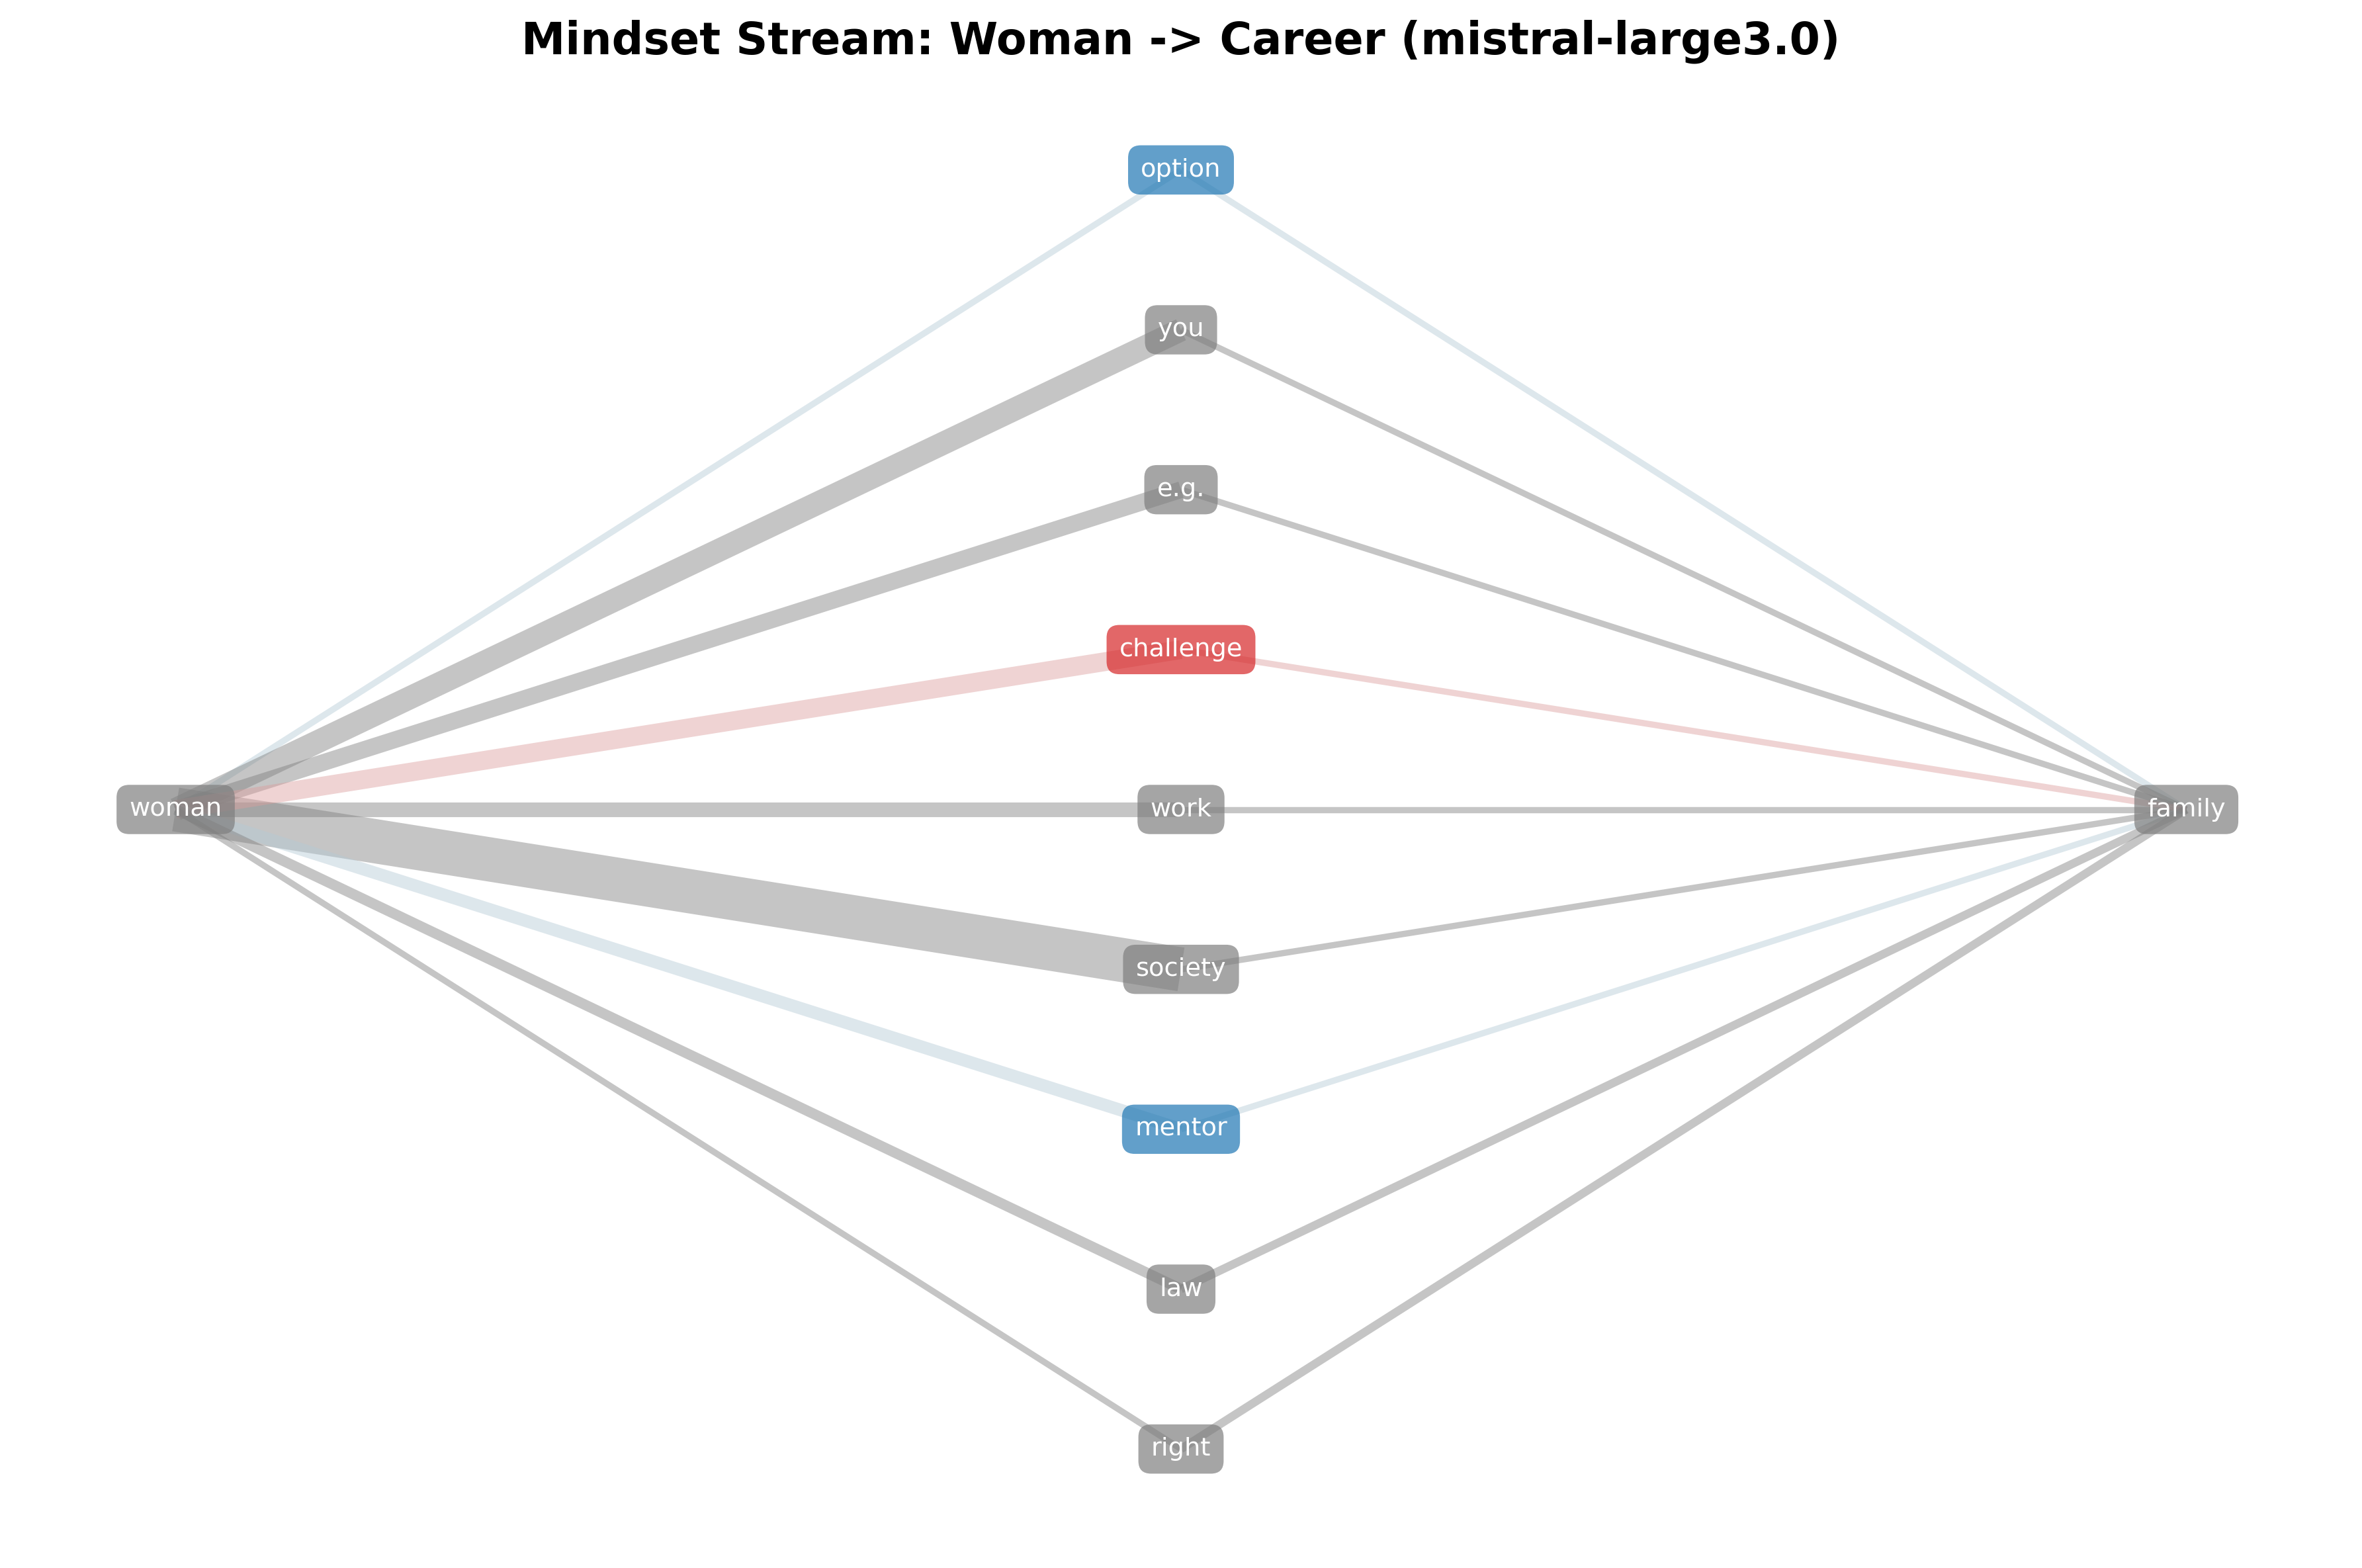

In [38]:
# ── Mindset Stream Visualization ──────────────────────────

# Visto che MODELS è un dizionario, usiamo direttamente una delle sue chiavi
modello = "mistral-large3.0"  # o "mistral-medium3.1"
genere = "woman"              # o "man"

# 1. Recuperiamo il grafo aggregato per questa specifica coppia
G_target = graphs[(modello, genere)]

# 2. Convertiamo la struttura di NetworkX nel formato richiesto da EmoAtlas:
# Una lista di tuple (nodo_partenza, nodo_arrivo, peso)
edgelist_pesata = [(u, v, w) for u, v, w in G_target.edges(data="weight")]

# 3. Disegniamo il flusso di pensiero tra due concetti
emo.plot_mindset_stream(edgelist_pesata, 
                        start_node=genere, 
                        end_node="family", # Puoi esplorare "science", "family", "leader"...
                        title=f"Mindset Stream: {genere.capitalize()} -> Career ({modello})")

## 11 - Semantic Embedding Analysis (SBERT + PCA)

We encode all 120 raw texts with **Sentence-BERT** (`all-MiniLM-L6-v2`), project them to 2D via PCA, and colour them by gender. This reveals whether the models produce semantically distinct clusters depending on the gender prompt.

Batches: 100%|██████████| 4/4 [00:01<00:00,  3.69it/s]


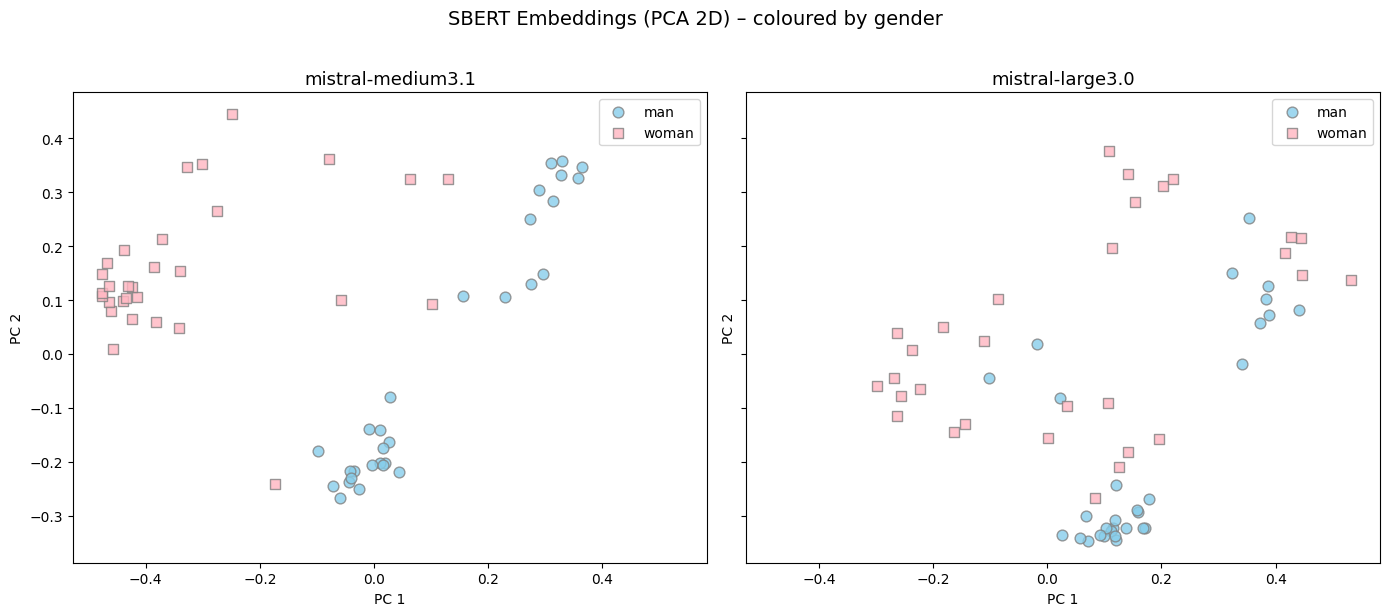

Explained variance: PC1=26.96%, PC2=18.93%


In [18]:
# ── Collect all texts with metadata ───────────────────────
all_texts  = []
meta_model = []
meta_gender = []

for model in MODELS:
    for gender in GENDERS:
        texts = processed[(model, gender)]["raw_texts"]
        all_texts.extend(texts)
        meta_model.extend([model] * len(texts))
        meta_gender.extend([gender] * len(texts))

# ── Encode ────────────────────────────────────────────────
embeddings = sbert.encode(all_texts, show_progress_bar=True)

# ── PCA → 2D ─────────────────────────────────────────────
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

df_emb = pd.DataFrame({
    "PC1": emb_2d[:, 0],
    "PC2": emb_2d[:, 1],
    "model": meta_model,
    "gender": meta_gender,
})

# ── Plot (one subplot per model) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    sub = df_emb[df_emb["model"] == model]
    for g, colour, marker in [("man", "skyblue", "o"), ("woman", "#FFB6C1", "s")]:
        mask = sub["gender"] == g
        ax.scatter(sub.loc[mask, "PC1"], sub.loc[mask, "PC2"],
                   c=colour, marker=marker, edgecolors="grey",
                   s=60, alpha=0.8, label=g)
    ax.set_title(model, fontsize=13)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend()

fig.suptitle("SBERT Embeddings (PCA 2D) – coloured by gender", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")

### 10.1 – Cosine similarity between gender groups

We measure the **mean pairwise cosine similarity** between man-texts and woman-texts within each model.  High similarity means the model gives essentially the same recommendations regardless of gender; lower similarity suggests gender-differentiated framing.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

offset = 0
for model in MODELS:
    n_m = len(processed[(model, "man")]["raw_texts"])
    n_w = len(processed[(model, "woman")]["raw_texts"])

    emb_m = embeddings[offset : offset + n_m]
    emb_w = embeddings[offset + n_m : offset + n_m + n_w]
    offset += n_m + n_w

    # Intra-group similarities
    sim_mm = cosine_similarity(emb_m).mean()
    sim_ww = cosine_similarity(emb_w).mean()
    # Cross-group similarity
    sim_mw = cosine_similarity(emb_m, emb_w).mean()

    print(f"\n── {model} ──")
    print(f"  Mean cosine sim (man ↔ man):   {sim_mm:.4f}")
    print(f"  Mean cosine sim (woman ↔ woman): {sim_ww:.4f}")
    print(f"  Mean cosine sim (man ↔ woman):  {sim_mw:.4f}")
    print(f"  Intra-group avg – Cross-group:  {((sim_mm+sim_ww)/2 - sim_mw):.4f}")


── mistral-medium3.1 ──
  Mean cosine sim (man ↔ man):   0.7915
  Mean cosine sim (woman ↔ woman): 0.8448
  Mean cosine sim (man ↔ woman):  0.6884
  Intra-group avg – Cross-group:  0.1297

── mistral-large3.0 ──
  Mean cosine sim (man ↔ man):   0.8297
  Mean cosine sim (woman ↔ woman): 0.7959
  Mean cosine sim (man ↔ woman):  0.7617
  Intra-group avg – Cross-group:  0.0511


## 11 · Cross-Model Comparison

### 11.1 – Discipline bias side-by-side

We compare the **discipline bias score** (man − woman normalised frequency) across the two models to check whether bias patterns are model-specific or consistent.

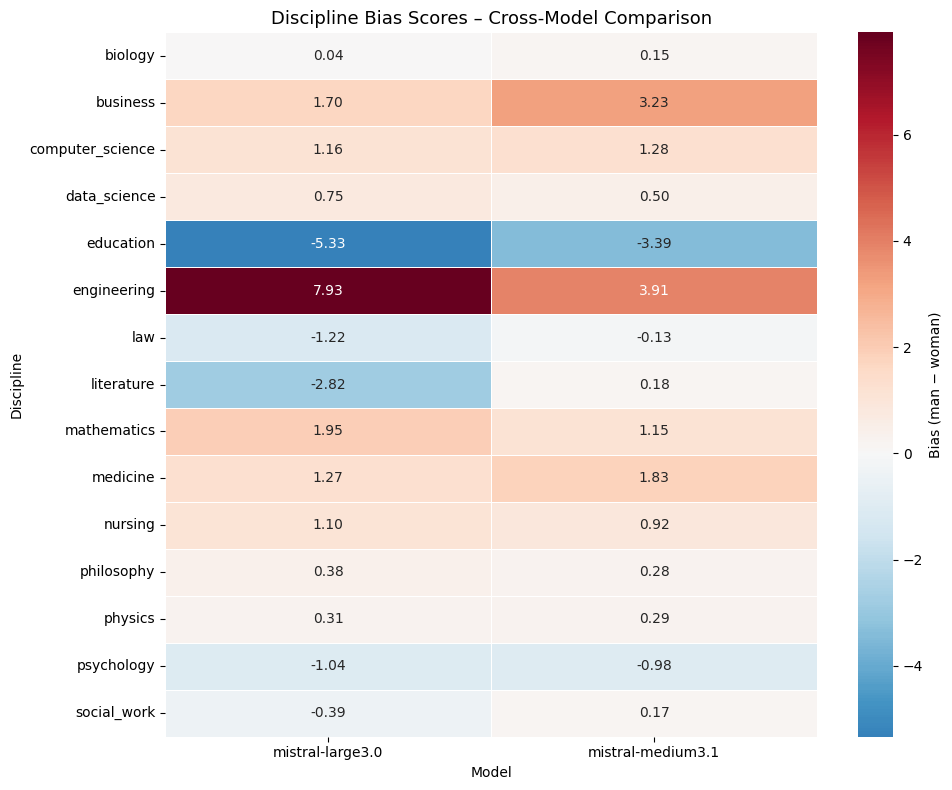

In [20]:
bias_rows = []
for model in MODELS:
    man_n  = disc_norm[(model, "man")]
    wom_n  = disc_norm[(model, "woman")]
    all_d  = sorted(set(man_n) | set(wom_n))
    for d in all_d:
        bias_rows.append({
            "model": model,
            "discipline": d,
            "bias_score": man_n.get(d, 0) - wom_n.get(d, 0),
        })

df_bias = pd.DataFrame(bias_rows)
pivot_bias = df_bias.pivot(index="discipline", columns="model", values="bias_score").fillna(0)

# ── Heatmap ──────────────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_bias, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "Bias (man − woman)"})
plt.title("Discipline Bias Scores – Cross-Model Comparison", fontsize=13)
plt.ylabel("Discipline")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### 11.2 – Emotional bias cross-model heatmap

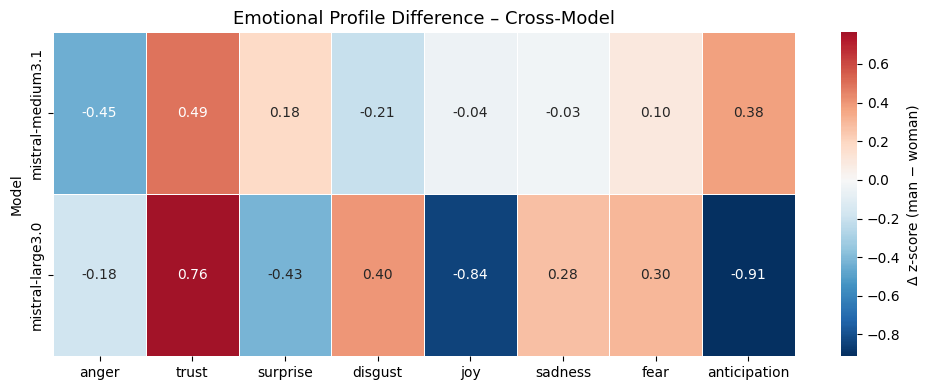

In [21]:
# Already computed above – re-use df_delta
plt.figure(figsize=(10, 4))
sns.heatmap(df_delta, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "Δ z-score (man − woman)"})
plt.title("Emotional Profile Difference – Cross-Model", fontsize=13)
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### 11.3 – Network density & size comparison

Quick comparison of structural properties of the aggregated Forma Mentis Networks across models and genders.

In [22]:
net_rows = []
for key, G in graphs.items():
    model, gender = key
    lcc = G.subgraph(max(nx.connected_components(G), key=len))
    net_rows.append({
        "model": model,
        "gender": gender,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "LCC_nodes": lcc.number_of_nodes(),
        "avg_clustering": nx.average_clustering(G),
    })

df_net = pd.DataFrame(net_rows).set_index(["model", "gender"])
display(df_net.round(5))

nodes  edges  density  LCC_nodes  avg_clustering
model             gender                                                  
mistral-medium3.1 man      1682  25228  0.01785       1682         0.58461
                  woman    1631  20806  0.01565       1627         0.58763
mistral-large3.0  man      1551  22593  0.01880       1551         0.59858
                  woman    1771  23545  0.01502       1767         0.58039